<div style="text-align: center; padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; border-radius: 10px; margin-bottom: 20px;">
    <h1 style="margin: 0;">Predicción de Calificación de Reseñas</h1>
    <h2 style="margin: 5px 0 0 0; font-weight: normal;">Restaurantes</h2>
</div>

<div style="text-align: center; padding: 10px; background-color: #f0f0f0; border-radius: 5px;">
    <p style="margin: 5px;"><strong>Javier Ramírez</strong></p>
    <p style="margin: 5px;">Clase: Reconocimiento de Patrones</p>
</div>

Clasificación multi-clase (1-5 estrellas) de reseñas de restaurantes.

    1: experiencia muy negativa.
    2: experiencia negativa.
    3: experiencia neutral o intermedia.
    4: experiencia positiva.
    5: experiencia muy positiva.



In [30]:
import pandas as pd
import numpy as np
import re
import html
import emoji
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, mean_squared_error, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

TRAIN_PATH = 'train/train.csv'
TEST_PATH = 'test_externo/test.csv'
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

---
## 1. Análisis Exploratorio de Datos

In [31]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train: {df_train.shape}")
print(f"Test: {df_test.shape}")
df_train.head()

Train: (7337, 4)
Test: (2473, 3)


,Restaurant,Reviewer,Review,Rating
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5


### 1.1 Distribución de clases

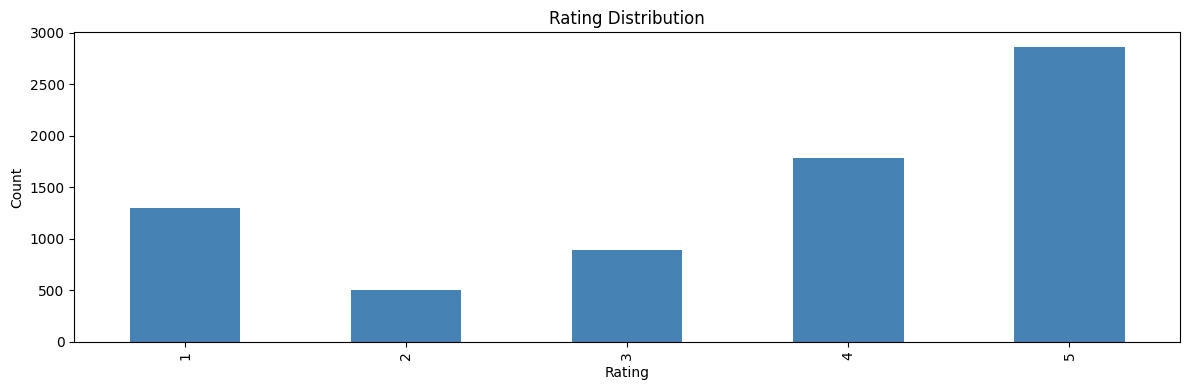

In [37]:
fig, axes = plt.subplots(figsize=(12, 4))  # Cambiado a una sola gráfica

df_train['Rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_rating_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Clase 2 (7%) es minoritaria con ~504 ejemplos. Ratio de desbalance 5.7x. Se maneja con class_weight balanced y SMOTE.

### 1.2 Análisis de longitud de texto

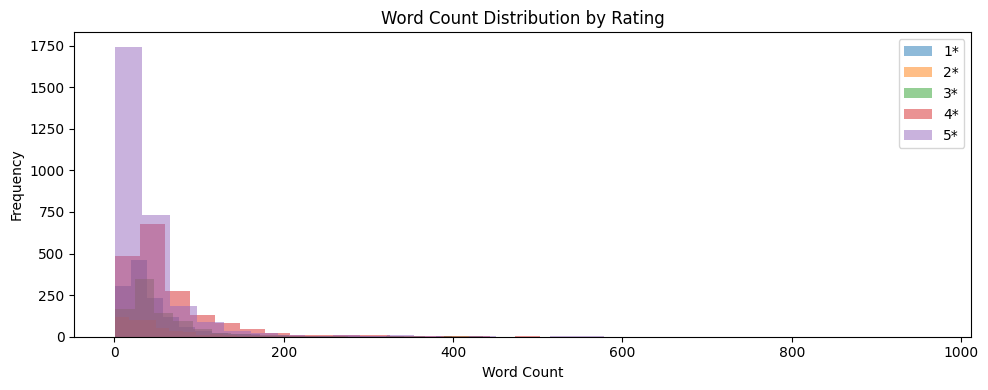

In [4]:
df_train['word_count'] = df_train['Review'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for rating in sorted(df_train['Rating'].unique()):
    subset = df_train[df_train['Rating'] == rating]
    ax.hist(subset['word_count'], alpha=0.5, label=f'{rating}*', bins=30)
ax.set_title('Word Count Distribution by Rating')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_word_count.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Palabras más frecuentes

In [44]:
!pip install nltk wordcloud -q

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jabonsote/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


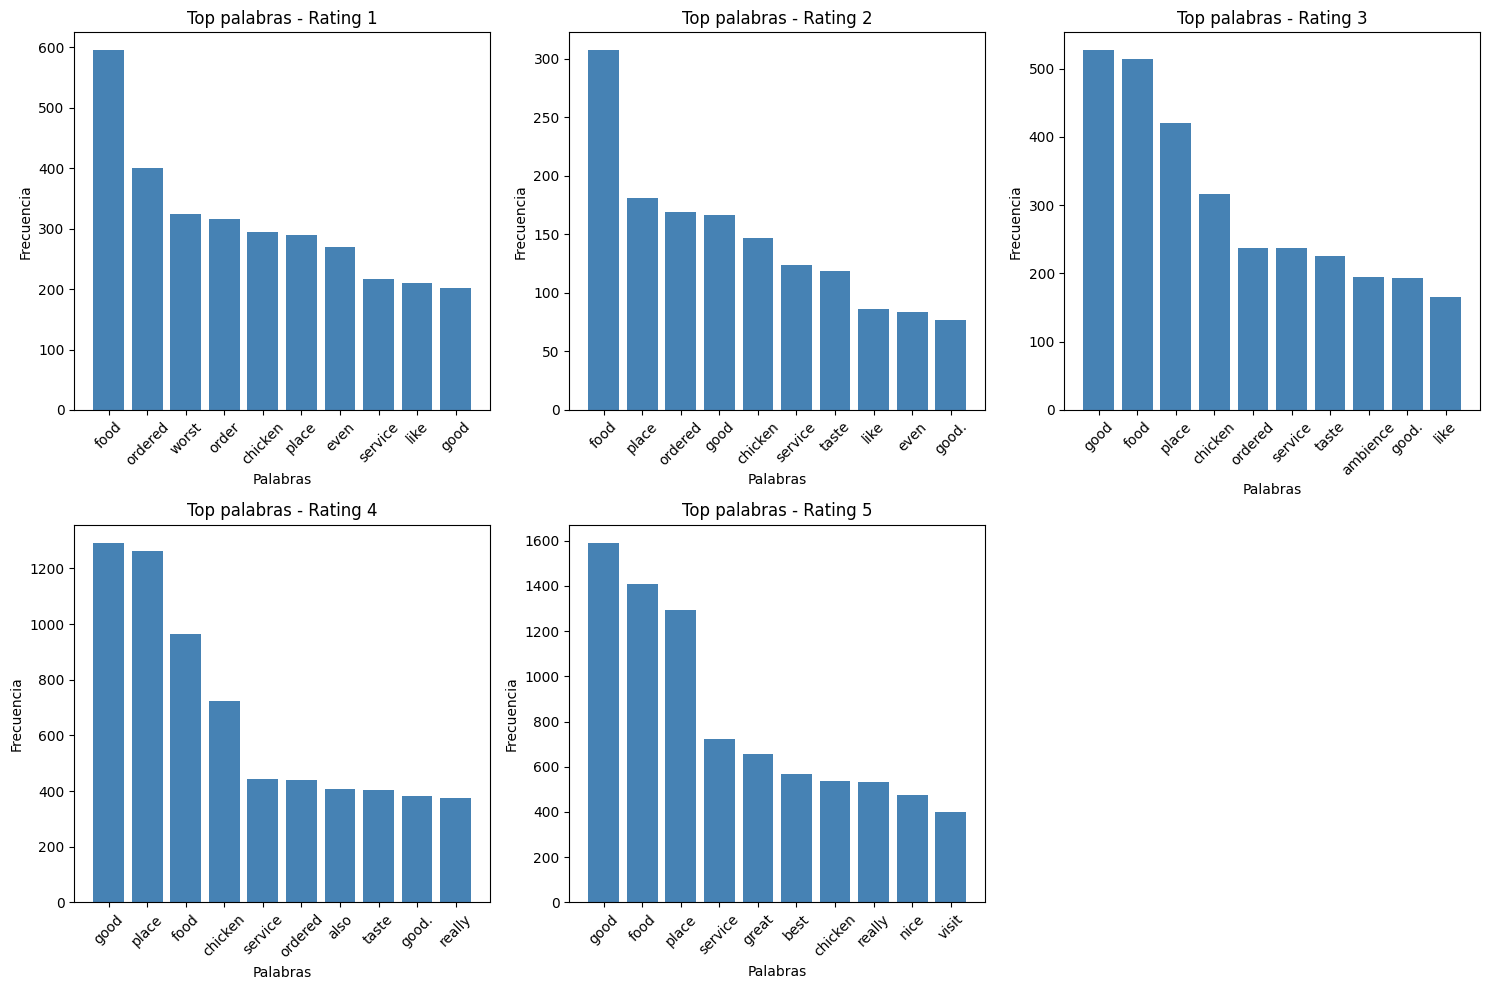

In [45]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ratings = sorted(df_train['Rating'].unique())

for idx, rating in enumerate(ratings):
    row = idx // 3
    col = idx % 3
    
    # Texto de reseñas con ese rating
    text = ' '.join(df_train[df_train['Rating'] == rating]['Review'])
    words = text.lower().split()
    words = [w for w in words if w not in stop_words and len(w) > 3]
    
    counter = Counter(words).most_common(10)
    words, counts = zip(*counter)
    
    axes[row, col].bar(words, counts, color='steelblue')
    axes[row, col].set_title(f'Top palabras - Rating {rating}')
    axes[row, col].set_xlabel('Palabras')
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 1.4 Nube de Palabras por Rating

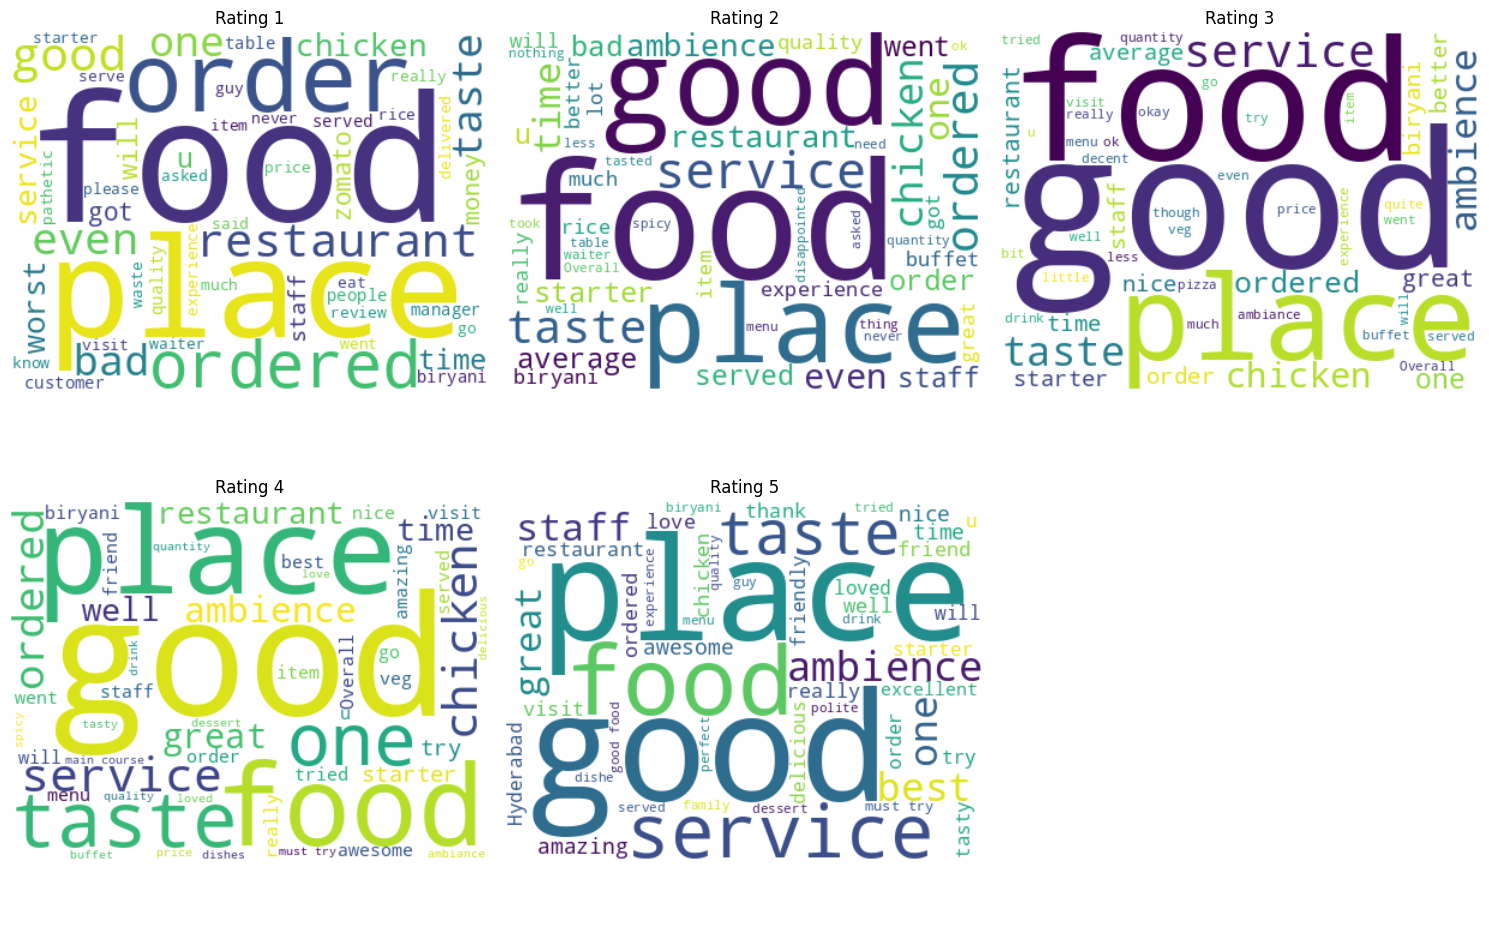

In [47]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ratings = sorted(df_train['Rating'].unique())

for idx, rating in enumerate(ratings):
    row = idx // 3
    col = idx % 3
    
    text = ' '.join(df_train[df_train['Rating'] == rating]['Review'])
    wordcloud = WordCloud(width=400, height=300, background_color='white', 
                         max_words=50, colormap='viridis').generate(text)
    
    axes[row, col].imshow(wordcloud, interpolation='bilinear')
    axes[row, col].axis('off')
    axes[row, col].set_title(f'Rating {rating}')
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

---
## 2. Preprocesamiento

Los modelos transformer entienden lenguaje natural, por eso no se eliminan stopwords ni se hace stemming, solamente los emojis se transforman a su expresión textual, ya que al revisarlo manualmente se encontraron emojis. :)

In [5]:
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(text)
    text = re.sub(r'[\n\r\t\f\v]+', ' ', text)
    text = emoji.demojize(text, language='en')
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train['clean_review'] = df_train['Review'].apply(preprocess_text)
df_test['clean_review'] = df_test['Review'].apply(preprocess_text)

print("Sample preprocessed reviews:")
for i in range(3):
    print(f"\n[{df_train['Rating'].iloc[i]}*] {df_train['clean_review'].iloc[i][:150]}")

Sample preprocessed reviews:

[5*] The ambience was good, food was quite good . had Saturday lunch , which was cost effective . Good place for a sate brunch. One can also chill with fri

[5*] Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service

[5*] A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also 


---
## 3. División Train/Val/Test

Split estratificado 70/15/15 antes de cualquier procesamiento para prevenir data leakage.

In [6]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    list(df_train['clean_review']),
    list(df_train['Rating']),
    test_size=0.15,
    random_state=SEED,
    stratify=list(df_train['Rating'])
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.176,
    random_state=SEED,
    stratify=y_trainval
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"\nTrain distribution: {dict(pd.Series(y_train).value_counts().sort_index())}")

Train: 5138, Val: 1098, Test: 1101

Train distribution: {1: np.int64(912), 2: np.int64(353), 3: np.int64(621), 4: np.int64(1249), 5: np.int64(2003)}


---
## 3.1 Manejo de desbalance de clases

Clase 2 tiene solo ~353 ejemplos (7%), clase 5 tiene ~2003 (39%). Se usa SMOTE para sobremuestrear clases minoritarias y class_weight para penalizar errores en clases minoritarias.

Class weights:
  Class 1: 1.127
  Class 2: 2.911
  Class 3: 1.655
  Class 4: 0.823
  Class 5: 0.513


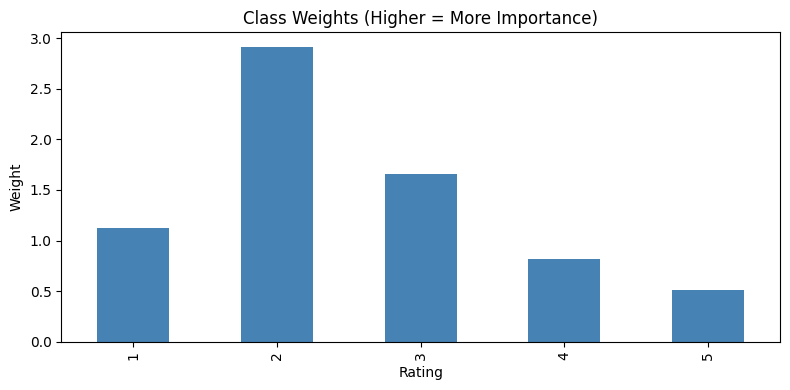

In [7]:
# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for c, w in class_weight_dict.items():
    print(f"  Class {c}: {w:.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(class_weight_dict).sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Class Weights (Higher = More Importance)')
ax.set_xlabel('Rating')
ax.set_ylabel('Weight')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Source - https://stackoverflow.com/a/62491442
# Posted by Marcus Lauritsen
# Retrieved 2026-08-09, License - CC BY-SA 4.0

!pip install imbalanced-learn -q

In [49]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print(f"Current train distribution: {dict(pd.Series(y_train).value_counts().sort_index())}")

Current train distribution: {1: np.int64(912), 2: np.int64(353), 3: np.int64(621), 4: np.int64(1249), 5: np.int64(2003)}


---
## 4. Comparación de modelos

Se comparan TF-IDF con LR/SVC, Sentence-BERT con LR/SVC, y SetFit.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
import joblib

results = {}

### 4.1 Modelos con TF-IDF

In [18]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")

TF-IDF shape: (5138, 15000)


In [19]:
# Apply SMOTE on TF-IDF features
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_tfidf_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"After SMOTE: {dict(pd.Series(y_train_balanced).value_counts().sort_index())}")

Before SMOTE: {1: np.int64(912), 2: np.int64(353), 3: np.int64(621), 4: np.int64(1249), 5: np.int64(2003)}
After SMOTE: {1: np.int64(2003), 2: np.int64(2003), 3: np.int64(2003), 4: np.int64(2003), 5: np.int64(2003)}


In [20]:
tfidf_models = {
    'tfidf_lr': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED),
    'tfidf_svc': LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=SEED),
}

for name, model in tfidf_models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf_balanced, y_train_balanced)
    
    y_pred_val = model.predict(X_val_tfidf)
    mcc = matthews_corrcoef(y_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    
    results[name] = {'mcc': mcc, 'rmse': rmse, 'model': model, 'type': 'tfidf'}
    print(f"  MCC: {mcc:.4f}, RMSE: {rmse:.4f}")
    
    joblib.dump(model, MODELS_DIR / f'{name}.joblib')

Training tfidf_lr...


/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


  MCC: 0.4962, RMSE: 0.8783
Training tfidf_svc...
  MCC: 0.4816, RMSE: 0.9292


### 4.2 Embeddings

In [21]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('BAAI/bge-large-en-v1.5')
#model_name = "BAAI/bge-large-en-v1.5"

X_train_emb = st_model.encode(X_train, batch_size=64, show_progress_bar=True)
X_val_emb = st_model.encode(X_val, batch_size=64, show_progress_bar=True)
X_test_emb = st_model.encode(X_test, batch_size=64, show_progress_bar=True)

print(f"Embeddings shape: {X_train_emb.shape}")

# Save embeddings
np.save(MODELS_DIR / 'X_train_emb.npy', X_train_emb)
np.save(MODELS_DIR / 'X_val_emb.npy', X_val_emb)
np.save(MODELS_DIR / 'X_test_emb.npy', X_test_emb)
np.save(MODELS_DIR / 'y_train.npy', y_train)
np.save(MODELS_DIR / 'y_val.npy', y_val)
np.save(MODELS_DIR / 'y_test.npy', y_test)

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Embeddings shape: (5138, 1024)


In [22]:
# Apply SMOTE on embeddings
X_train_emb_balanced, y_train_emb_balanced = smote.fit_resample(X_train_emb, y_train)

print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"After SMOTE: {dict(pd.Series(y_train_emb_balanced).value_counts().sort_index())}")

Before SMOTE: {1: np.int64(912), 2: np.int64(353), 3: np.int64(621), 4: np.int64(1249), 5: np.int64(2003)}
After SMOTE: {1: np.int64(2003), 2: np.int64(2003), 3: np.int64(2003), 4: np.int64(2003), 5: np.int64(2003)}


In [23]:
emb_models = {
    'emb_lr': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED),
    'emb_svc': LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=SEED),
}

for name, model in emb_models.items():
    print(f"Training {name}...")
    model.fit(X_train_emb_balanced, y_train_emb_balanced)
    
    y_pred_val = model.predict(X_val_emb)
    mcc = matthews_corrcoef(y_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    
    results[name] = {'mcc': mcc, 'rmse': rmse, 'model': model, 'type': 'embeddings'}
    print(f"  MCC: {mcc:.4f}, RMSE: {rmse:.4f}")
    
    joblib.dump(model, MODELS_DIR / f'{name}.joblib')

Training emb_lr...


/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


  MCC: 0.5959, RMSE: 0.7045
Training emb_svc...
  MCC: 0.5548, RMSE: 0.7466


### 4.3 SetFit

SetFit usa aprendizaje contrastivo para fine-tuning eficiente de Sentence Transformers.

In [11]:
from setfit import SetFitModel, SetFitTrainer
from sentence_transformers.losses import CosineSimilarityLoss
from datasets import Dataset

model_name = "all-MiniLM-L6-v2"
print(f"Loading model: {model_name}")

setfit_model = SetFitModel.from_pretrained(model_name)

Loading model: all-MiniLM-L6-v2


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


In [12]:
# Oversample minority classes for SetFit
from collections import Counter

# Get class distribution
class_counts = Counter(y_train)
max_count = max(class_counts.values())

# Oversample each class to max_count
X_train_oversampled = []
y_train_oversampled = []

for class_label in sorted(class_counts.keys()):
    class_indices = [i for i, y in enumerate(y_train) if y == class_label]
    class_texts = [X_train[i] for i in class_indices]
    
    # Repeat to reach max_count
    n_repeats = max_count // len(class_indices)
    n_remaining = max_count % len(class_indices)
    
    X_train_oversampled.extend(class_texts * n_repeats)
    X_train_oversampled.extend(class_texts[:n_remaining])
    y_train_oversampled.extend([class_label] * max_count)

print(f"Before oversampling: {dict(Counter(y_train))}")
print(f"After oversampling: {dict(Counter(y_train_oversampled))}")

Before oversampling: {3: 621, 4: 1249, 5: 2003, 1: 912, 2: 353}
After oversampling: {1: 2003, 2: 2003, 3: 2003, 4: 2003, 5: 2003}


In [14]:
train_dataset = Dataset.from_dict({"text": X_train_oversampled, "label": y_train_oversampled})
eval_dataset = Dataset.from_dict({"text": X_val, "label": y_val})

trainer = SetFitTrainer(
    model=setfit_model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss_class=CosineSimilarityLoss,
    batch_size=16,
    num_iterations=5,
    num_epochs=1,
    column_mapping={"text": "text", "label": "label"}
)

print("Training SetFit with oversampled data...")
trainer.train()
print("Training complete.")

/tmp/ipykernel_40742/1265233883.py:4: DeprecationWarning: `SetFitTrainer` has been deprecated and will be removed in v2.0.0 of SetFit. Please use `Trainer` instead.
  trainer = SetFitTrainer(
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset


Map:   0%|          | 0/10015 [00:00<?, ? examples/s]

Training SetFit with oversampled data...


***** Running training *****
  Num unique pairs = 100150
  Batch size = 16
  Num epochs = 1
/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss
1,0.125400
50,0.186100
100,0.178700
150,0.181400
200,0.171600
250,0.172500
300,0.193300
350,0.174400
400,0.174800
450,0.168900


/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/home/jabonsote/miniconda3/envs/vjepa2-312/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/home

Training complete.


In [15]:
y_pred_val_setfit = setfit_model.predict(X_val)
mcc_setfit = matthews_corrcoef(y_val, y_pred_val_setfit)
rmse_setfit = np.sqrt(mean_squared_error(y_val, y_pred_val_setfit))

results['setfit'] = {'mcc': mcc_setfit, 'rmse': rmse_setfit, 'model': setfit_model, 'type': 'setfit'}
print(f"SetFit - MCC: {mcc_setfit:.4f}, RMSE: {rmse_setfit:.4f}")

setfit_model.save_pretrained(MODELS_DIR / 'setfit_model')

SetFit - MCC: 0.5649, RMSE: 0.6948


---
## 5. Comparación de modelos

=== Model Comparison (Validation Set) ===
                MCC      RMSE
emb_lr     0.595941  0.704526
emb_svc    0.554846  0.746577
tfidf_lr   0.496169  0.878295
tfidf_svc  0.481637  0.929187


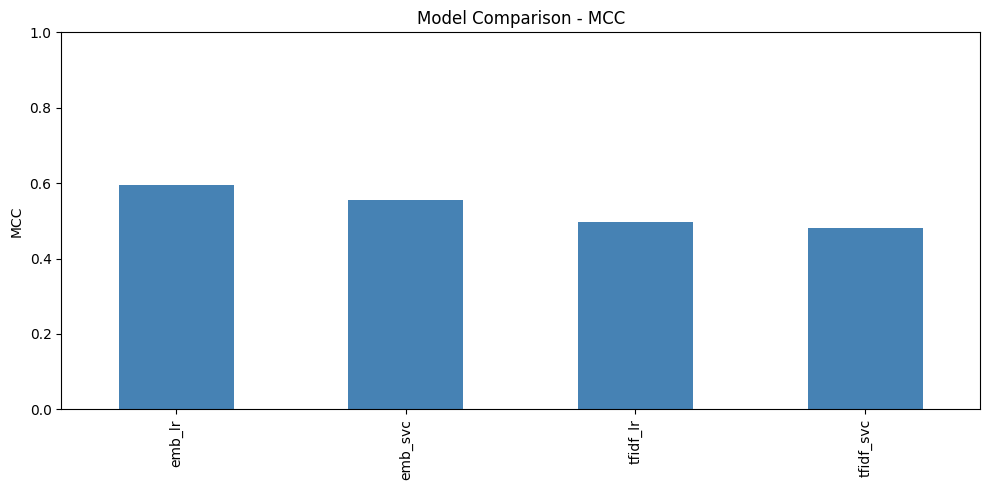

In [24]:
comparison_df = pd.DataFrame({
    name: {'MCC': r['mcc'], 'RMSE': r['rmse']}
    for name, r in results.items()
}).T.sort_values('MCC', ascending=False)

print("=== Model Comparison (Validation Set) ===")
print(comparison_df)

comparison_df.to_csv(MODELS_DIR / 'model_comparison.csv')

fig, ax = plt.subplots(figsize=(10, 5))
comparison_df['MCC'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Model Comparison - MCC')
ax.set_ylabel('MCC')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Evaluación del mejor modelo en test interno

In [25]:
best_model_name = comparison_df.index[0]
best_model = results[best_model_name]['model']
best_model_type = results[best_model_name]['type']

print(f"Best model: {best_model_name} (MCC: {comparison_df.iloc[0]['MCC']:.4f})")

if best_model_type == 'tfidf':
    y_pred_test = best_model.predict(X_test_tfidf)
elif best_model_type == 'embeddings':
    y_pred_test = best_model.predict(X_test_emb)
elif best_model_type == 'setfit':
    y_pred_test = best_model.predict(X_test)

mcc_test = matthews_corrcoef(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
accuracy_test = np.mean(y_test == y_pred_test)

print(f"\n=== Internal Test Metrics ===")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"MCC: {mcc_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_test))

Best model: emb_lr (MCC: 0.5959)

=== Internal Test Metrics ===
Accuracy: 0.6730
MCC: 0.5620
RMSE: 0.7370

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.77      0.78       195
           2       0.32      0.42      0.36        76
           3       0.46      0.46      0.46       133
           4       0.58      0.60      0.59       268
           5       0.84      0.79      0.81       429

    accuracy                           0.67      1101
   macro avg       0.60      0.61      0.60      1101
weighted avg       0.69      0.67      0.68      1101



---
## 7. Análisis de errores

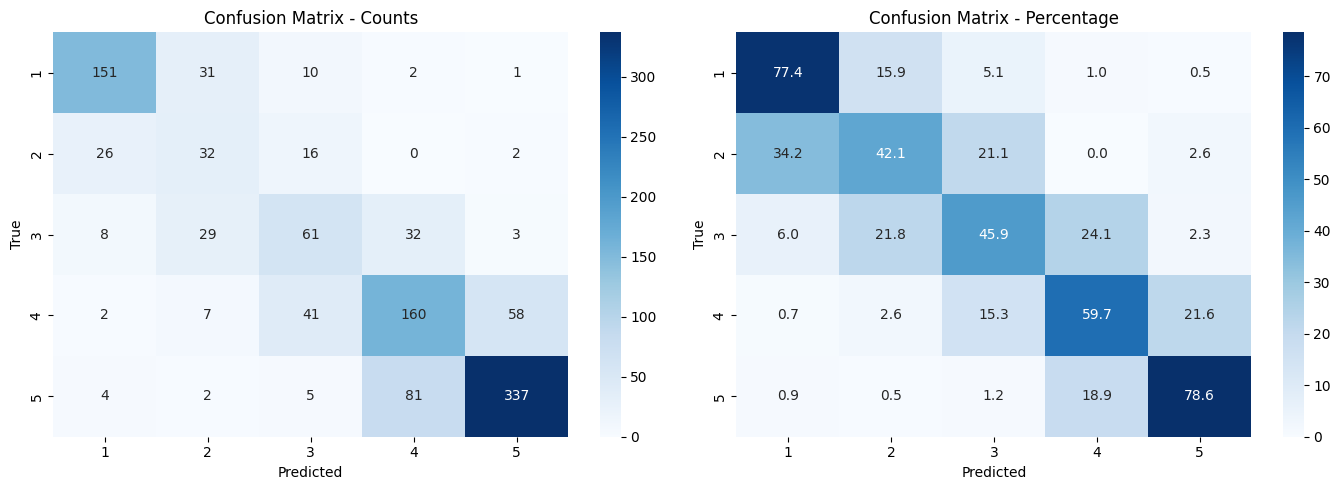

In [26]:
cm_test = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticklabels([1, 2, 3, 4, 5])
axes[0].set_yticklabels([1, 2, 3, 4, 5])

cm_pct = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentage')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticklabels([1, 2, 3, 4, 5])
axes[1].set_yticklabels([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Predicciones finales

In [28]:
X_external = list(df_test['clean_review'])

if best_model_type == 'tfidf':
    X_external_vec = tfidf.transform(X_external)
    y_pred_external = best_model.predict(X_external_vec)
elif best_model_type == 'embeddings':
    X_external_emb = st_model.encode(X_external, batch_size=64)
    y_pred_external = best_model.predict(X_external_emb)
elif best_model_type == 'setfit':
    y_pred_external = best_model.predict(X_external)

print(f"Prediction distribution:")
print(pd.Series(y_pred_external).value_counts().sort_index())

Prediction distribution:
1    415
2    235
3    292
4    611
5    920
Name: count, dtype: int64


In [29]:
predicciones = pd.DataFrame({'Rating': y_pred_external.astype(int)})
predicciones.to_csv('predicciones_v3.csv', index=False)

print(f"Saved {len(predicciones)} predictions to predicciones_v3.csv")
print(f"\nFirst 10 predictions:")
print(predicciones.head(10))

Saved 2473 predictions to predicciones_v3.csv

First 10 predictions:
   Rating
0       5
1       5
2       5
3       5
4       5
5       3
6       5
7       5
8       5
9       5
